In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df=pd.read_csv('car_data_augmented.csv')

In [3]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
446,corolla altis,2008,2.20,14.68,48002,Petrol,Individual,Manual,0
447,alto k10,2005,0.51,3.41,104744,Diesel,Dealer,Manual,0
448,TVS Wego,2018,0.34,0.45,8924,Petrol,Dealer,Manual,0
449,corolla altis,2015,10.90,15.47,19628,Petrol,Dealer,Automatic,0


# Business problem:
## A company wants to estimate the selling price of a used car based on vehicle characteristics.

## Objective:

### Build a machine learning model that predicts the selling price of a car.

In [4]:
print(df.shape)



(451, 9)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       451 non-null    object 
 1   Year           451 non-null    int64  
 2   Selling_Price  451 non-null    float64
 3   Present_Price  451 non-null    float64
 4   Kms_Driven     451 non-null    int64  
 5   Fuel_Type      451 non-null    object 
 6   Seller_Type    451 non-null    object 
 7   Transmission   451 non-null    object 
 8   Owner          451 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 31.8+ KB
None


In [6]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [7]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [8]:
df.duplicated().sum()

2

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

0

In [11]:
print(df.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   449.000000     449.000000     449.000000     449.000000  449.000000
mean   2012.503341       3.996258       7.884811   43896.449889    0.044543
std       3.786797       4.558321       8.331465   38426.110967    0.263515
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2010.000000       0.750000       1.470000   17500.000000    0.000000
50%    2014.000000       2.900000       6.790000   36198.000000    0.000000
75%    2015.000000       5.500000      10.000000   60076.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [12]:
df['Selling_Price'].describe()

count    449.000000
mean       3.996258
std        4.558321
min        0.100000
25%        0.750000
50%        2.900000
75%        5.500000
max       35.000000
Name: Selling_Price, dtype: float64

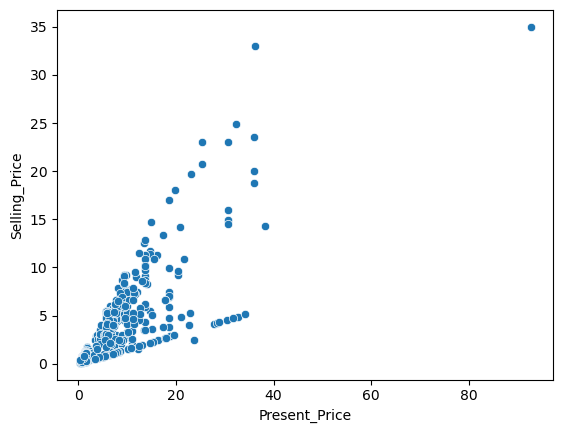

In [13]:
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.show()

In [14]:
df.corr(numeric_only=True)['Selling_Price']

Year             0.335957
Selling_Price    1.000000
Present_Price    0.794477
Kms_Driven      -0.124347
Owner           -0.067856
Name: Selling_Price, dtype: float64

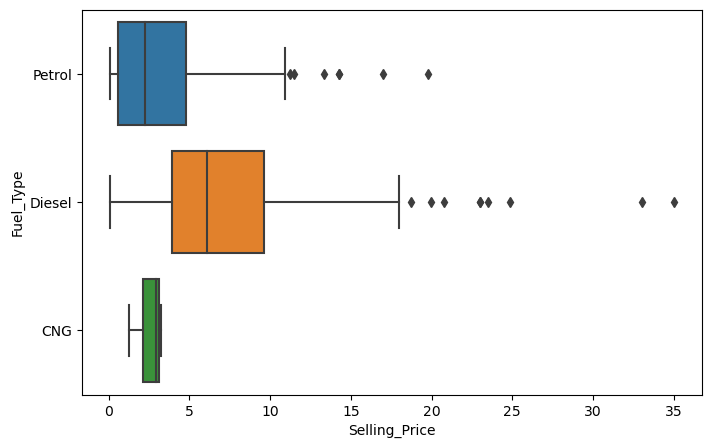

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Selling_Price', y='Fuel_Type', data=df)
plt.show()

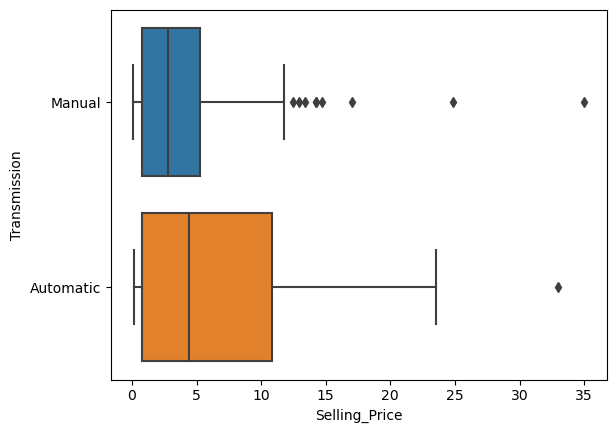

In [16]:
sns.boxplot(x='Selling_Price', y='Transmission', data=df)
plt.show()

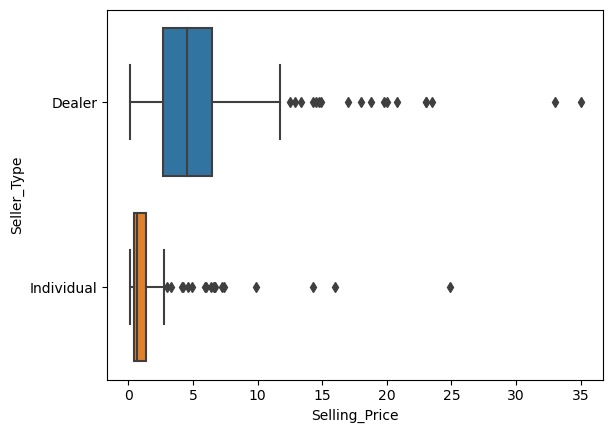

In [17]:
sns.boxplot(x='Selling_Price', y='Seller_Type', data=df)
plt.show()

In [18]:
Current_year = datetime.now().year

In [19]:
df['Car_age']= Current_year - df['Year']

C:\Users\nihil\AppData\Local\Temp\ipykernel_34780\2763624867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Car_age']= Current_year - df['Year']


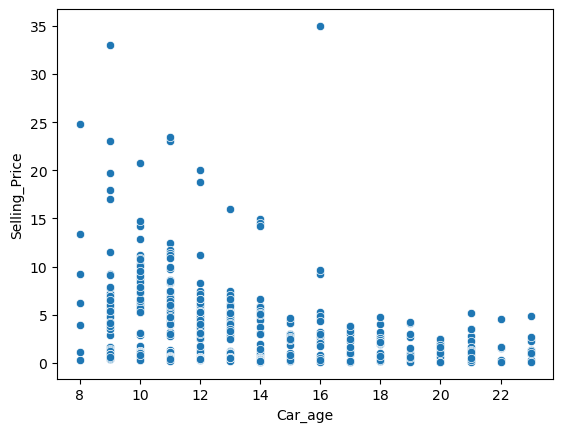

In [20]:
sns.scatterplot(x='Car_age', y='Selling_Price', data=df)
plt.show()

In [21]:
df.corr(numeric_only=True)['Selling_Price']

Year             0.335957
Selling_Price    1.000000
Present_Price    0.794477
Kms_Driven      -0.124347
Owner           -0.067856
Car_age         -0.335957
Name: Selling_Price, dtype: float64

In [22]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
Car_age          0
dtype: int64

In [23]:
df.duplicated().sum()

0

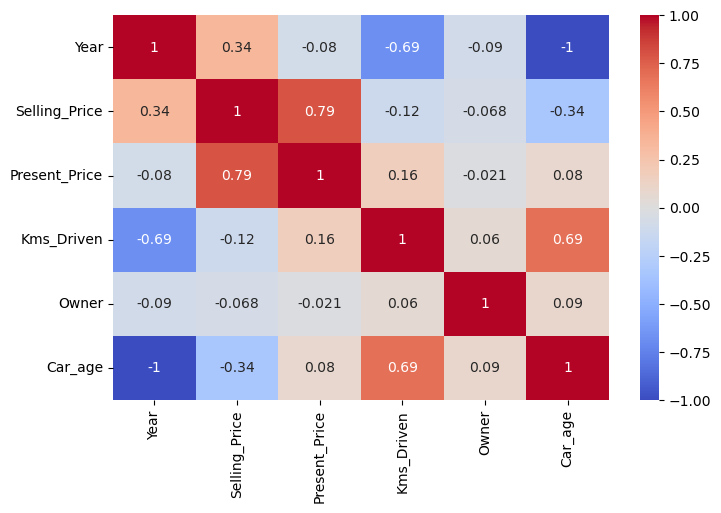

In [24]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [25]:
df.drop('Year', axis=1, inplace=True)

C:\Users\nihil\AppData\Local\Temp\ipykernel_34780\1294706632.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('Year', axis=1, inplace=True)


In [26]:
df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [27]:
df.select_dtypes(include='object').columns

Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')